# xgboost Modelling Results

Jimmy Butler
November 2025

In [1]:
import pandas as pd
import xarray as xr
import xgboost as xgb
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LinearRegression
import json

from interpretation_utils import *
from cross_validation.cv_utils import predictive_r2
import shap

## Snow Model

Below are the best hyperparameters that we found.

In [2]:
with open('cross_validation/best_snow_xgb.json', 'r') as file:
        best_snow = json.load(file)

In [3]:
best_snow

{'gamma': 0.15,
 'max_depth': 8.0,
 'reg_lambda': 10.0,
 'min_child_weight': 0.2,
 'subsample_frac': 0.2,
 'eta': 0.05,
 'num_boost': 231.0,
 'shrinkage_factor': 0.995843272061652}

In [4]:
# creating the dictionary of hyperparameters for training

hyperparam_dict = {}
hyperparam_dict['gamma'] = float(best_snow['gamma'])
hyperparam_dict['max_depth'] = int(best_snow['max_depth'])
hyperparam_dict['reg_lambda'] = float(best_snow['reg_lambda'])
hyperparam_dict['min_child_weight'] = float(best_snow['min_child_weight'])
hyperparam_dict['eta'] = float(best_snow['eta'])
hyperparam_dict['booster'] = 'gbtree'
hyperparam_dict['tree_method'] = 'exact'
hyperparam_dict['objective'] = 'reg:squarederror'
hyperparam_dict['eval_metric'] = 'rmse'
num_boost = int(best_snow['num_boost'])
shrinkage_factor = best_snow['shrinkage_factor']

In [5]:
load_path = Path(os.getcwd()).parents[1]/'dataset/datasets/model_ready'

In [6]:
# creating training and test data objects

train_data = pd.read_csv(load_path/'train.csv', index_col='Label')
test_data = pd.read_csv(load_path/'test.csv', index_col='Label')
y_col = 'cumulative_snowfall_ais'
x_cols = ['max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'avg_landfalling_minomega', 'max_IWV_ais', 'cumulative_landfalling_area', 'max_south_extent']

X_train = train_data[x_cols]
y_train = train_data[y_col]
X_test = test_data[x_cols]
y_test = test_data[y_col]
y_train_centered = y_train - y_train.mean()
y_test_centered = y_test - y_train.mean()

X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])


In [7]:
# training linear regression on CLA to obtain residuals

linreg = LinearRegression(fit_intercept=False)
x_cla_mean = X_train['cumulative_landfalling_area'].mean()
x_cla_centered = X_train['cumulative_landfalling_area'] - x_cla_mean
linear_fit = linreg.fit(X=pd.DataFrame(x_cla_centered), y=y_train_centered)
resid = y_train_centered - linear_fit.predict(pd.DataFrame(x_cla_centered))

In [8]:
# training the residual model

model_snow = xgb.XGBRegressor(n_estimators=num_boost, 
                     max_depth=hyperparam_dict['max_depth'], 
                     learning_rate=hyperparam_dict['eta'],
                     booster=hyperparam_dict['booster'],
                     tree_method=hyperparam_dict['tree_method'],
                     gamma=hyperparam_dict['gamma'],
                     min_child_weight=hyperparam_dict['min_child_weight'],
                     reg_lambda=hyperparam_dict['reg_lambda'],
                     objective='reg:squarederror',
                     eval_metric='rmse')

resid_fit = model_snow.fit(X_train, resid)

In [9]:
def prediction_snow(X, y_train, linear_fit, resid_fit, shrinkage_factor, centered=False):
    pred = shrinkage_factor*(resid_fit.predict(X) + 
                      linear_fit.predict(pd.DataFrame(X['cumulative_landfalling_area'] - x_cla_mean)))

    if not centered:
        return pred + y_train.mean()

    return pred

In [10]:
y_test_pred = prediction_snow(X_test, y_train, linear_fit, resid_fit, shrinkage_factor)
y_train_pred = prediction_snow(X_train, y_train, linear_fit, resid_fit, shrinkage_factor)

In [11]:
## training predictive r-squared
train_pred_r2 = predictive_r2(y_train_pred, y_train)

## testing predictive r-squared
test_pred_r2 = predictive_r2(y_test_pred, y_test)

## ols baseline
reg = LinearRegression().fit(X_train, y_train_centered)
y_pred_ols = reg.predict(X_test) + y_train.mean()
test_ols_r2 = predictive_r2(y_pred_ols, y_test)

### Model Performance

Predictive $R^{2}$ on the training data

In [12]:
train_res = round(float(train_pred_r2), 3)
train_res

0.949

In [13]:
test_res = round(float(test_pred_r2), 3)
test_res

0.881

In [14]:
test_ols = round(float(test_ols_r2), 3)
test_ols

0.826

How much closer did our prediction scheme get us to perfection, relative to OLS?

In [15]:
(test_res - test_ols)/(1-test_ols)

0.31609195402298873

This is pretty good! Our model closed 30% of the gap to perfection that existed with OLS.

### Model Interpretation

First, we look at variable importance metrics by way of permutation scores, where for each variable, we randomly permute the observations in that column and compute how much the error increases. We repeat this multiple times to get an average.

Upon getting a sense of which variables are the most important in predicting snowfall *in the context of this model*, we then further interrogate the model with 1D and 2D partial dependence plots to explore how the model makes predictions when holding other variables fixed.

In [16]:
importances = get_permutation_importance(lambda X: prediction_snow(X, y_train=y_train, linear_fit=linear_fit, resid_fit=resid_fit, shrinkage_factor=shrinkage_factor),
                               X_full, y_full, predictive_r2, maximize=True, n_repeats=500)

/tmp/ipykernel_2428365/4172389616.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels);


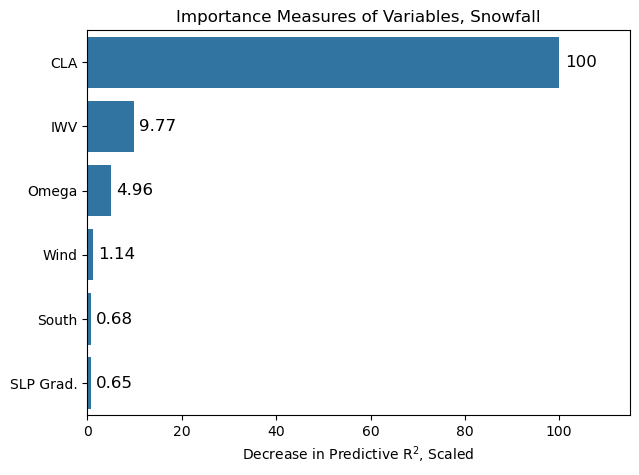

In [17]:
importances = importances.round(4)

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=importances, y=importances.index, x=importances.avg_importance_scaled*100, ax=ax)
ax.set_title('Importance Measures of Variables, Snowfall')
ax.set_xlabel('Decrease in Predictive R$^{2}$, Scaled')
ax.set_xlim([0,115])
ax.set_ylabel('')
ax.bar_label(ax.containers[0], padding=4, fontsize=12)
new_labels = ['CLA', 'IWV', 'Omega', 'Wind', 'South', 'SLP Grad.']
ax.set_yticklabels(new_labels);
fig.savefig('plots/importance_snow.png', dpi=300)

Let's first plot all of the partial dependence plots.

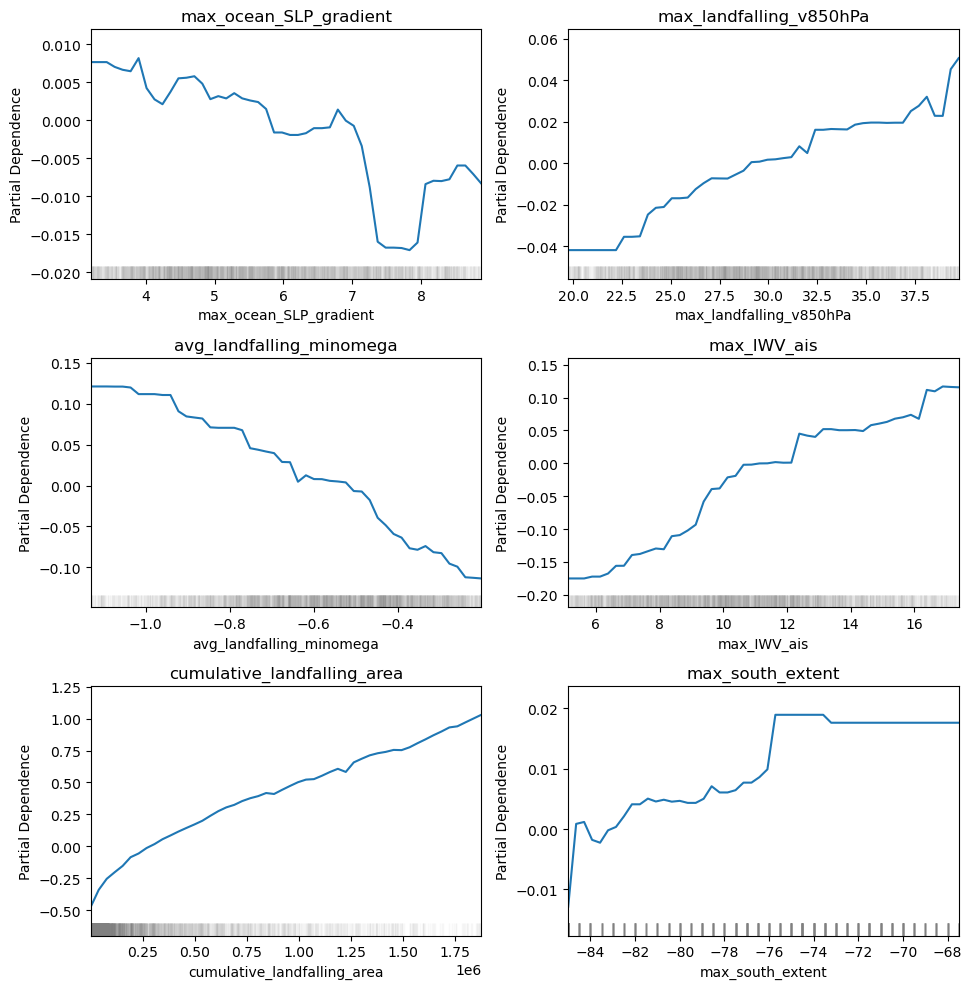

In [141]:
fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(10, 10))
axs = axs.flatten()
features = list(X_full.columns)

for i, ax in enumerate(axs):

    q = 0.05
    extents = [X_full[features[i]].quantile(q),
              X_full[features[i]].quantile(1-q)]
    
    grid, pdp_vals = compute_pdp_1d(features[i], 
                                              X_full, lambda X: prediction_snow(X, 
                                                                        y_train=y_train, 
                                                                        linear_fit=linear_fit,
                                                                        resid_fit=resid_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True),
                                    extents=extents)
    ax.plot(grid, pdp_vals)
    sns.rugplot(x=X_full[features[i]], ax=ax, height=0.05, color='gray', alpha=0.05)
    ax.set_xlim(extents[0], extents[1])
    ax.set_title(features[i])
    ax.set_ylabel('Partial Dependence')

plt.tight_layout()
plt.savefig('snowfall_1d_pdp_full.png', dpi=300)

Now, let's isolate the top 4 as far as variable importances go, and plot them on the same set of axes.

In [45]:
abbv_dict = {variables[0]: 'SLP',
             variables[1]: 'Wind',
             variables[2]: 'Omega',
             variables[3]: 'IWV',
             variables[4]: 'CLA',
             variables[5]: 'South'}

units_dict = {variables[0]: 'hPa/km',
              variables[1]: 'm/s',
              variables[2]: 'Pa/s',
              variables[3]: 'kg/m$^{2}$',
              variables[4]: 'km$^{2}$ day',
              variables[5]: 'deg. lat.'}

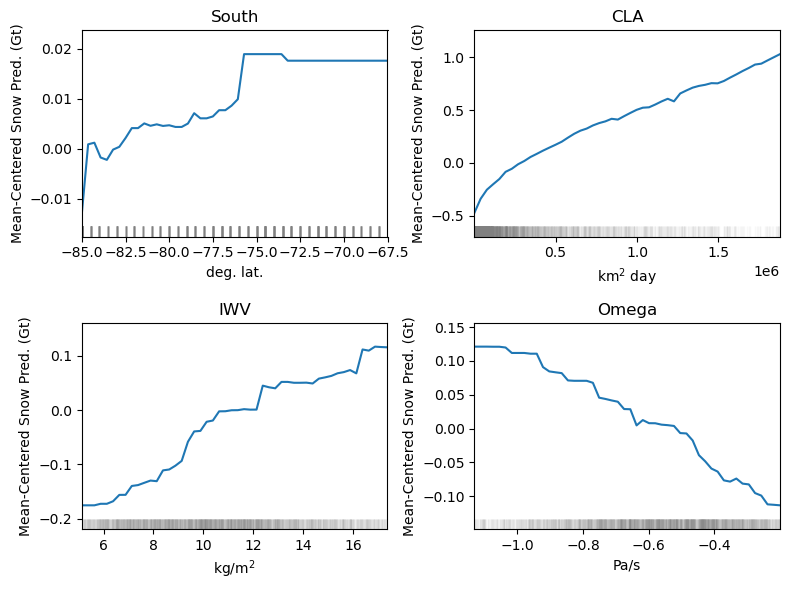

In [142]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(8, 6))
axs = axs.flatten()
features = list(importances.index[0:4]) # top 4 in variable importance

for i, ax in enumerate(axs):

    q = 0.05
    extents = [X_full[features[i]].quantile(q),
              X_full[features[i]].quantile(1-q)]
    
    grid, pdp_vals = compute_pdp_1d(features[i], 
                                              X_full, lambda X: prediction_snow(X, 
                                                                        y_train=y_train, 
                                                                        linear_fit=linear_fit,
                                                                        resid_fit=resid_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True),
                                    extents=extents)
    ax.plot(grid, pdp_vals)
    sns.rugplot(x=X_full[features[i]], ax=ax, height=0.05, color='gray', alpha=0.05)
    ax.set_xlim(extents[0], extents[1])
    ax.set_xlabel(units_dict[features[i]])
    ax.set_title(abbv_dict[features[i]])
    ax.set_ylabel('Mean-Centered Snow Pred. (Gt)')

plt.tight_layout()
plt.savefig('snowfall_1d_pdp_subset.png', dpi=300)

Interpretation: Holding all other variables fixed, increasing CLA gives the biggest increases in snowfall predictions on average. Increasing IWV leads to higher snowfall predictions, lower omega leads to higher snowfall predictions, and higher wind leads to higher snowfall predictions, but the effect of wind on model predictions is much smaller than the other variables.

This is more informative than scatter plots for example, since we are now asking our model to give us predictions varying one of these variables *and holding all other features fixed* to isolate the effect of individual variables on model predictions. CAUTION: this is the effect on *model predictions*, not necessarily real-world effects. Nonetheless, it can still be informative because obviously the model picked up on patterns, and so it can illuminate future routes of study for mechanisms of ARs. 

Now, what if we vary two variables at once and hold all others fixed? This will help illuminate any interactions that our model may have picked up on in the dataset. Maybe the effect of one variable on model predictions depends on the value of another variable? 2D PDPs will be of help here.

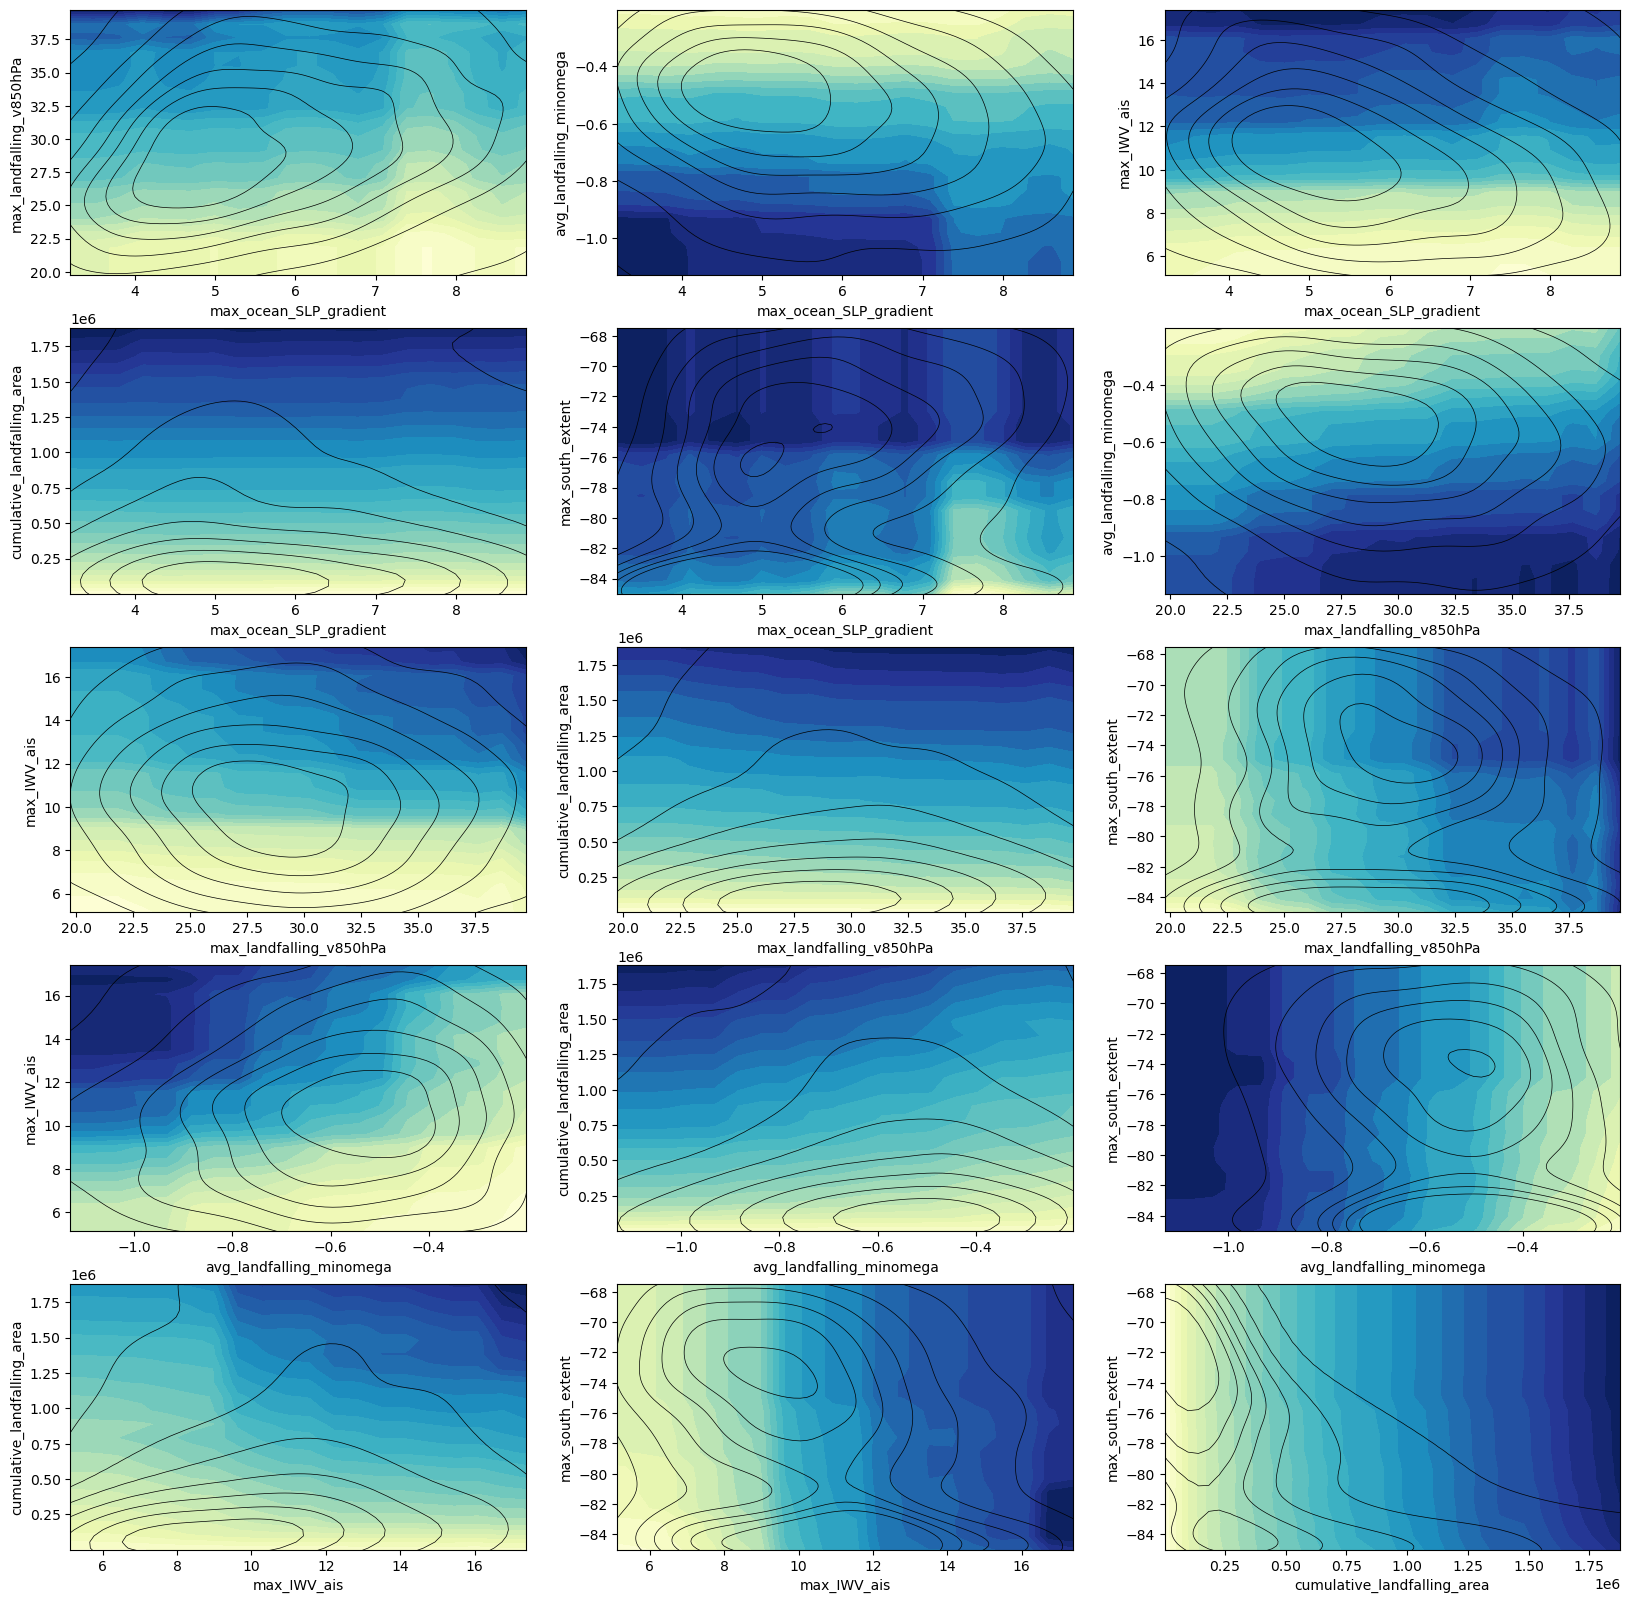

In [105]:
import itertools
combos = list(itertools.combinations(X_test.columns, 2))

fig, axs = plt.subplots(ncols=3, nrows=5, figsize=(20, 20))

axs = axs.flatten()

for i, ax in enumerate(axs):
    combo = combos[i]

    q = 0.05 # quantile to clip data
    extents = [X_full[combo[0]].quantile(q), 
               X_full[combo[0]].quantile(1-q),
               X_full[combo[1]].quantile(q),
               X_full[combo[1]].quantile(1-q)]

    grid1, grid2, pdp_matrix = compute_pdp_2d(combo[0], combo[1], 
                                              X_full, lambda X: prediction_snow(X, 
                                                                        y_train=y_train, 
                                                                        linear_fit=linear_fit,
                                                                        resid_fit=resid_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True),
                                              extents=extents)
    ax.contourf(grid1, grid2, pdp_matrix, cmap='YlGnBu', levels=25)
    sns.kdeplot(x=X_full[combo[0]], y=X_full[combo[1]], ax=ax, levels=8, color="black", linewidths=0.5, fill=False)
    ax.set_ylim(min(grid2), max(grid2))
    ax.set_xlim(min(grid1), max(grid1))
    ax.set_xlabel(combo[0])
    ax.set_ylabel(combo[1])

plt.savefig('snowfall_2d_pdp_full.png', dpi=300)

Below, we choose to isolate interactions between the second most important variable (IWV), and the other three of the four most important variables (by way of the permutation score). 

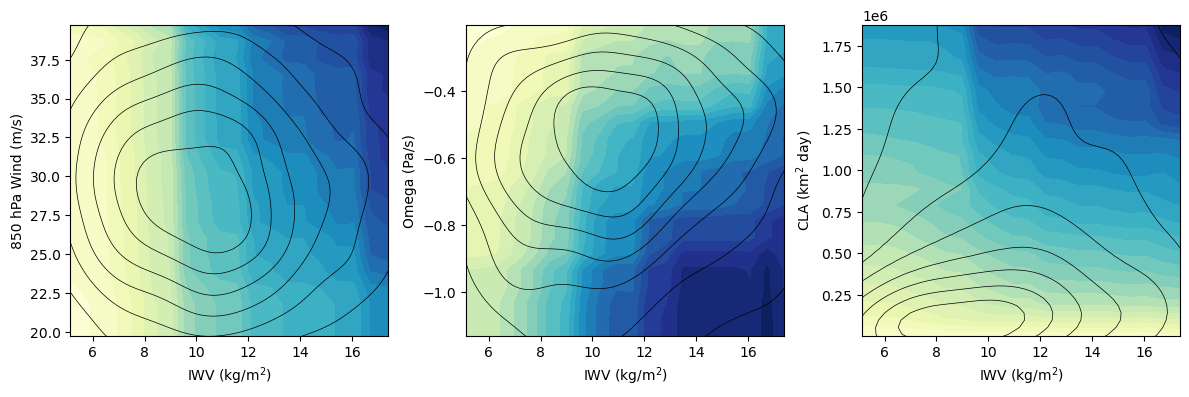

In [18]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))

axs = axs.flatten()

combos = [('max_IWV_ais', 'max_landfalling_v850hPa'),
          ('max_IWV_ais', 'avg_landfalling_minomega'),
          ('max_IWV_ais', 'cumulative_landfalling_area')]

for i, ax in enumerate(axs):
    combo = combos[i]

    q = 0.05 # quantile to clip data
    extents = [X_full[combo[0]].quantile(q), 
               X_full[combo[0]].quantile(1-q),
               X_full[combo[1]].quantile(q),
               X_full[combo[1]].quantile(1-q)]
    grid1, grid2, pdp_matrix = compute_pdp_2d(combo[0], combo[1], 
                                              X_full, lambda X: prediction_snow(X, 
                                                                        y_train=y_train, 
                                                                        linear_fit=linear_fit,
                                                                        resid_fit=resid_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True),
                                             extents=extents)
    ax.contourf(grid1, grid2, pdp_matrix, cmap='YlGnBu', levels=25)
    sns.kdeplot(x=X_full[combo[0]], y=X_full[combo[1]], ax=ax, levels=8, color="black", linewidths=0.5, fill=False)
    ax.set_ylim(min(grid2), max(grid2))
    ax.set_xlim(min(grid1), max(grid1))
    ax.set_xlabel(combo[0])
    ax.set_ylabel(combo[1])

plt.tight_layout()

axs[0].set_ylabel('850 hPa Wind (m/s)')
axs[0].set_xlabel('IWV (kg/m$^{2}$)')
axs[1].set_ylabel('Omega (Pa/s)')
axs[1].set_xlabel('IWV (kg/m$^{2}$)')
axs[2].set_ylabel('CLA (km$^{2}$ day)')
axs[2].set_xlabel('IWV (kg/m$^{2}$)')

plt.savefig('plots/snowfall_2d_pdp_subset.png', dpi=300)

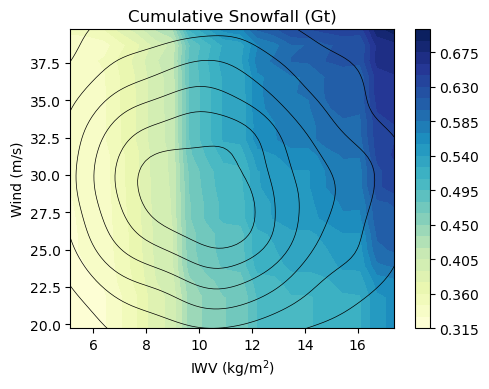

In [29]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(5, 4))

combos = [('max_IWV_ais', 'max_landfalling_v850hPa'),
          ('max_IWV_ais', 'avg_landfalling_minomega'),
          ('max_IWV_ais', 'cumulative_landfalling_area')]

combo = combos[0]

q = 0.05 # quantile to clip data
extents = [X_full[combo[0]].quantile(q), 
               X_full[combo[0]].quantile(1-q),
               X_full[combo[1]].quantile(q),
               X_full[combo[1]].quantile(1-q)]
grid1, grid2, pdp_matrix = compute_pdp_2d(combo[0], combo[1], 
                                              X_full, lambda X: prediction_snow(X, 
                                                                        y_train=y_train, 
                                                                        linear_fit=linear_fit,
                                                                        resid_fit=resid_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=False),
                                             extents=extents)
contour = ax.contourf(grid1, grid2, pdp_matrix, cmap='YlGnBu', levels=25)
sns.kdeplot(x=X_full[combo[0]], y=X_full[combo[1]], ax=ax, levels=8, color="black", linewidths=0.5, fill=False)
ax.set_ylim(min(grid2), max(grid2))
ax.set_xlim(min(grid1), max(grid1))
ax.set_xlabel(combo[0])
ax.set_ylabel(combo[1])

plt.tight_layout()

ax.set_ylabel('Wind (m/s)')
ax.set_xlabel('IWV (kg/m$^{2}$)')
ax.set_title('Cumulative Snowfall (Gt)')

fig.colorbar(contour, ax=ax)
plt.tight_layout()
plt.savefig('plots/AGU_snow_2D_PDP_Wind_IWV.png', dpi=300)

Interpretation:
+ (left) holding all other variables fixed, increasing both wind and IWV leads to higher snowfall predictions. However, there are some interesting interactions: for fixed IWV, increasing the wind speed doesn't seem to do much at all for snowfall predictions until we have higher IWV. However, for fixed windspeed, no matter how small, increasing the IWV leads to higher snowfall predictions. This validates what we saw in our bivariate exploratory plots: that high wind-speed is not a necessary condition for increased snowfall. However, as wind-speed increases, the effect of IWV on snowfall predictions increases.
+ (middle) holding all other variables fixed, increasing both IWV and Omega leads to higher snowfall predictions. But it's asymmetric: jacking omega up for small IWV doesn't produce as high snowfall predictions as jacking up IWV for low omega. Similarly, if you fix IWV at a high value, the rate of increase in snowfall predictions is smaller per unit omega, than if we fix omega at a high value and increase moisture content. So, IWV and omega interact to produce snowfall predictions.
+ (right) more moist storms that spend more time over the ice sheet have higher snowfall predictions, holding all other variables constant. Increasing IWV leads to steeper increases in snowfall predictions as CLA increases. And increasing CLA leads to steeper increases in snowfall predictions as IWV increases. You can see that they interact a bit, but that CLA is the dominant force in generating these predictions.

Significance:
+ Moisture dominated ARs have higher snowfall predictions than wind-dominated ARs, and wind-speed only begins to play a role in snowfall predictions with higher IWV storms. However, IWV increases snowfall predictions for all wind speeds, with the increases becoming more steep as wind increases. If a storm is relatively dry, increasing the wind speed doesn't produce as much snowfall, and doesn't lead to nearly as demonstrable increases in snowfall output.
+ Lift interacts with moisture such that the more lifting, the higher the predicted snowfall per unit increase of IWV. Omega clearly plays a bigger role here than wind.


#### SHAP Analysis

Another tool in our toolkit to interrogate/reason about models is by way of Shapley values. This is a little bit more difficult to explain and interpret for a non-statistical audience, but they are a very useful tool for ascribing importance of variables in generating predictions for individual storms. They also explore the model in different ways than above, and thus can be seen as a robustness check on the aforementioned results.

In [59]:
explainer_xgb = shap.Explainer(resid_fit, X_train)

In [60]:
import matplotlib.pyplot as plt

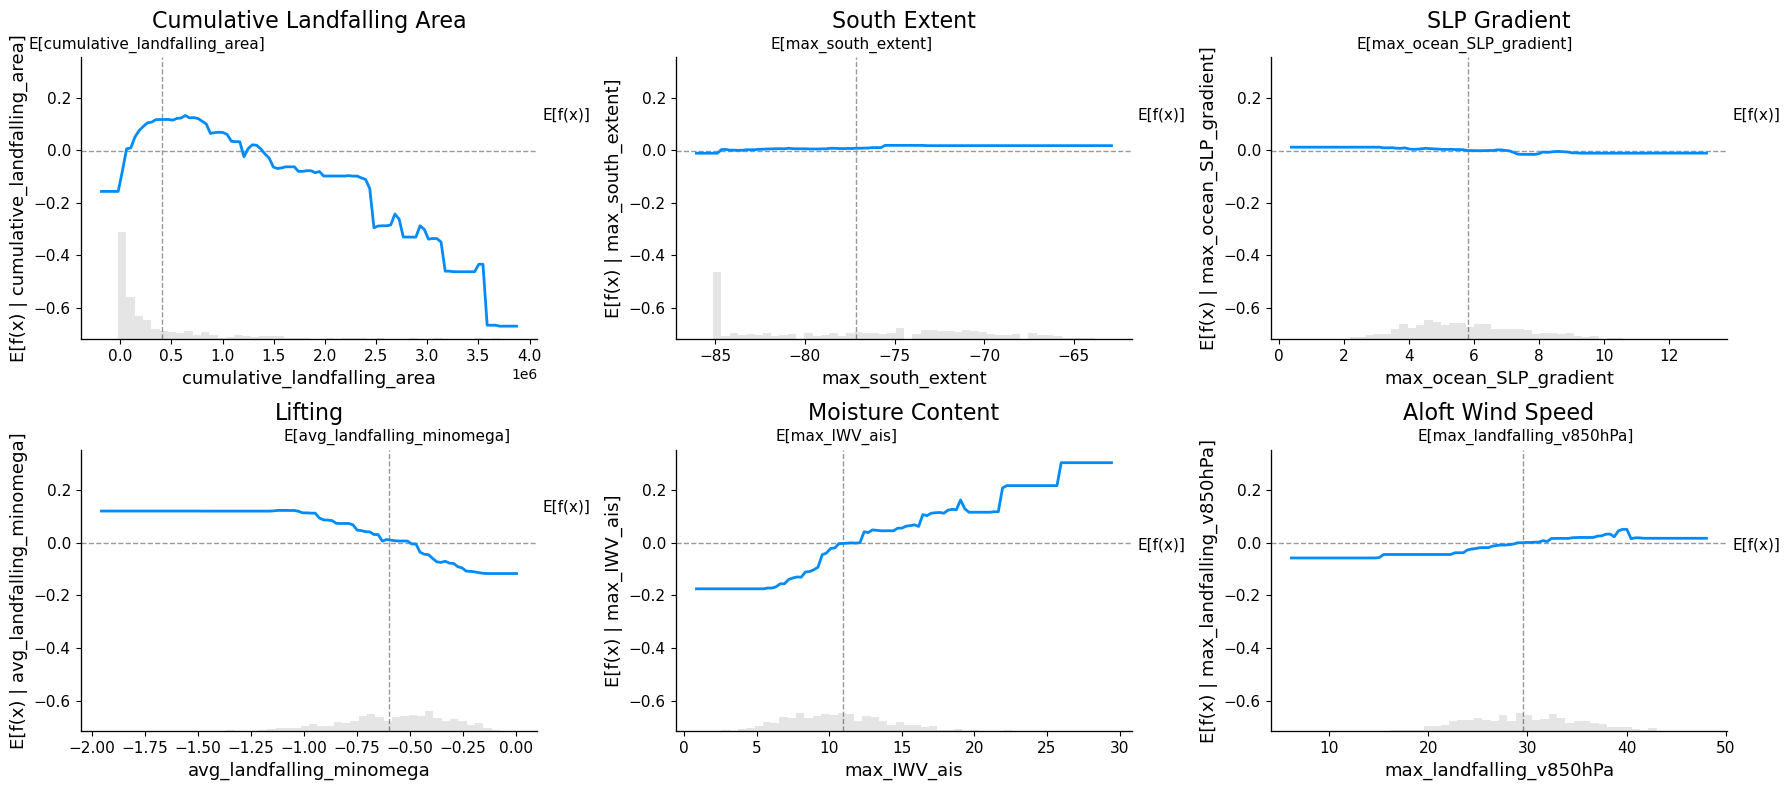

In [66]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 8), sharey=True)

plt.sca(axes[0,0])
shap.partial_dependence_plot(
    "cumulative_landfalling_area",
    resid_fit.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[0,0]
)

axes[0,0].set_title('Cumulative Landfalling Area', fontsize=16);

plt.sca(axes[0,1])
shap.partial_dependence_plot(
    "max_south_extent",
    resid_fit.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[0,1]
)

axes[0,1].set_title('South Extent', fontsize=16);

plt.sca(axes[0,2])
shap.partial_dependence_plot(
    "max_ocean_SLP_gradient",
    resid_fit.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[0,2]
)

axes[0,2].set_title('SLP Gradient', fontsize=16);

plt.sca(axes[1,0])
shap.partial_dependence_plot(
    "avg_landfalling_minomega",
    resid_fit.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[1,0]
)

axes[1,0].set_title('Lifting', fontsize=16);

plt.sca(axes[1,1])
shap.partial_dependence_plot(
    "max_IWV_ais",
    resid_fit.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[1,1]
)

axes[1,1].set_title('Moisture Content', fontsize=16);

plt.sca(axes[1,2])
shap.partial_dependence_plot(
    "max_landfalling_v850hPa",
    resid_fit.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[1,2]
)
axes[1,2].set_title('Aloft Wind Speed', fontsize=16);

plt.tight_layout()
plt.show()

#axes[0,0].set_title('Cumulative Landfalling Area');

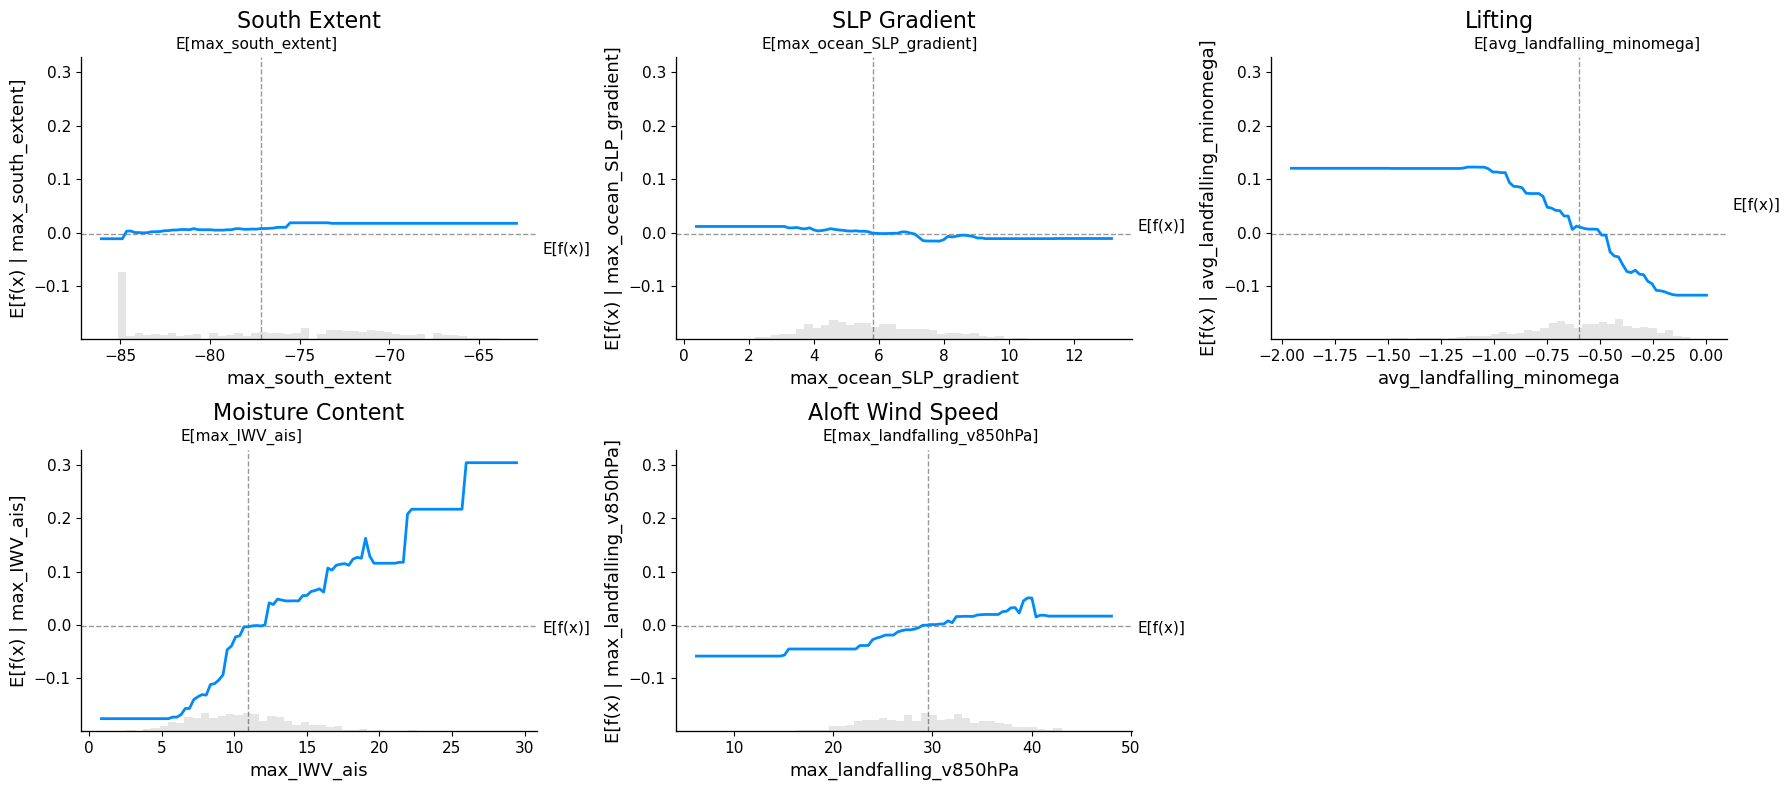

In [69]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 8), sharey=True)

plt.sca(axes[0,0])
shap.partial_dependence_plot(
    "max_south_extent",
    resid_fit.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[0,0]
)

axes[0,0].set_title('South Extent', fontsize=16);

plt.sca(axes[0,1])
shap.partial_dependence_plot(
    "max_ocean_SLP_gradient",
    resid_fit.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[0,1]
)

axes[0,1].set_title('SLP Gradient', fontsize=16);

plt.sca(axes[0,2])
shap.partial_dependence_plot(
    "avg_landfalling_minomega",
    resid_fit.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[0,2]
)

axes[0,2].set_title('Lifting', fontsize=16);

plt.sca(axes[1,0])
shap.partial_dependence_plot(
    "max_IWV_ais",
    resid_fit.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[1,0]
)

axes[1,0].set_title('Moisture Content', fontsize=16);

plt.sca(axes[1,1])
shap.partial_dependence_plot(
    "max_landfalling_v850hPa",
    resid_fit.predict,
    X_test,
    ice=False,
    model_expected_value=True,
    feature_expected_value=True,
    show=False,
    ax=axes[1,1]
)
axes[1,1].set_title('Aloft Wind Speed', fontsize=16);
fig.delaxes(axes[1,2])

plt.tight_layout()
plt.show()

In [74]:
X_test.columns

Index(['max_ocean_SLP_gradient', 'max_landfalling_v850hPa',
       'avg_landfalling_minomega', 'max_IWV_ais',
       'cumulative_landfalling_area', 'max_south_extent'],
      dtype='object')

In [73]:
shap_values_xgb = explainer_xgb(X_test)
np.mean(np.abs(shap_values_xgb.values), axis = 0)

array([0.00733609, 0.01753659, 0.0533273 , 0.08546531, 0.09894318,
       0.01498047])

In [109]:
FULL_FEATURE_NAMES = X_train.columns

def prediction_snow(X):
    X_df = pd.DataFrame(X, columns=FULL_FEATURE_NAMES)
    pred = y_train.mean() + shrinkage_factor*(resid_fit.predict(X_df) + 
                      linear_fit.predict(pd.DataFrame(X_df.iloc[:, 4] - x_cla_mean)))

    return pred

explainer_full = shap.KernelExplainer(
    model=prediction_snow,
    data=X_train
)

Using 2481 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [110]:
%%time
shap_values = explainer_full.shap_values(X_test)

  0%|          | 0/620 [00:00<?, ?it/s]

CPU times: user 3min 51s, sys: 113 ms, total: 3min 52s
Wall time: 3min 52s


In [113]:
np.mean(np.abs(shap_values), axis = 0)

array([0.00627124, 0.01806886, 0.05419948, 0.08329675, 0.37033387,
       0.01411763])

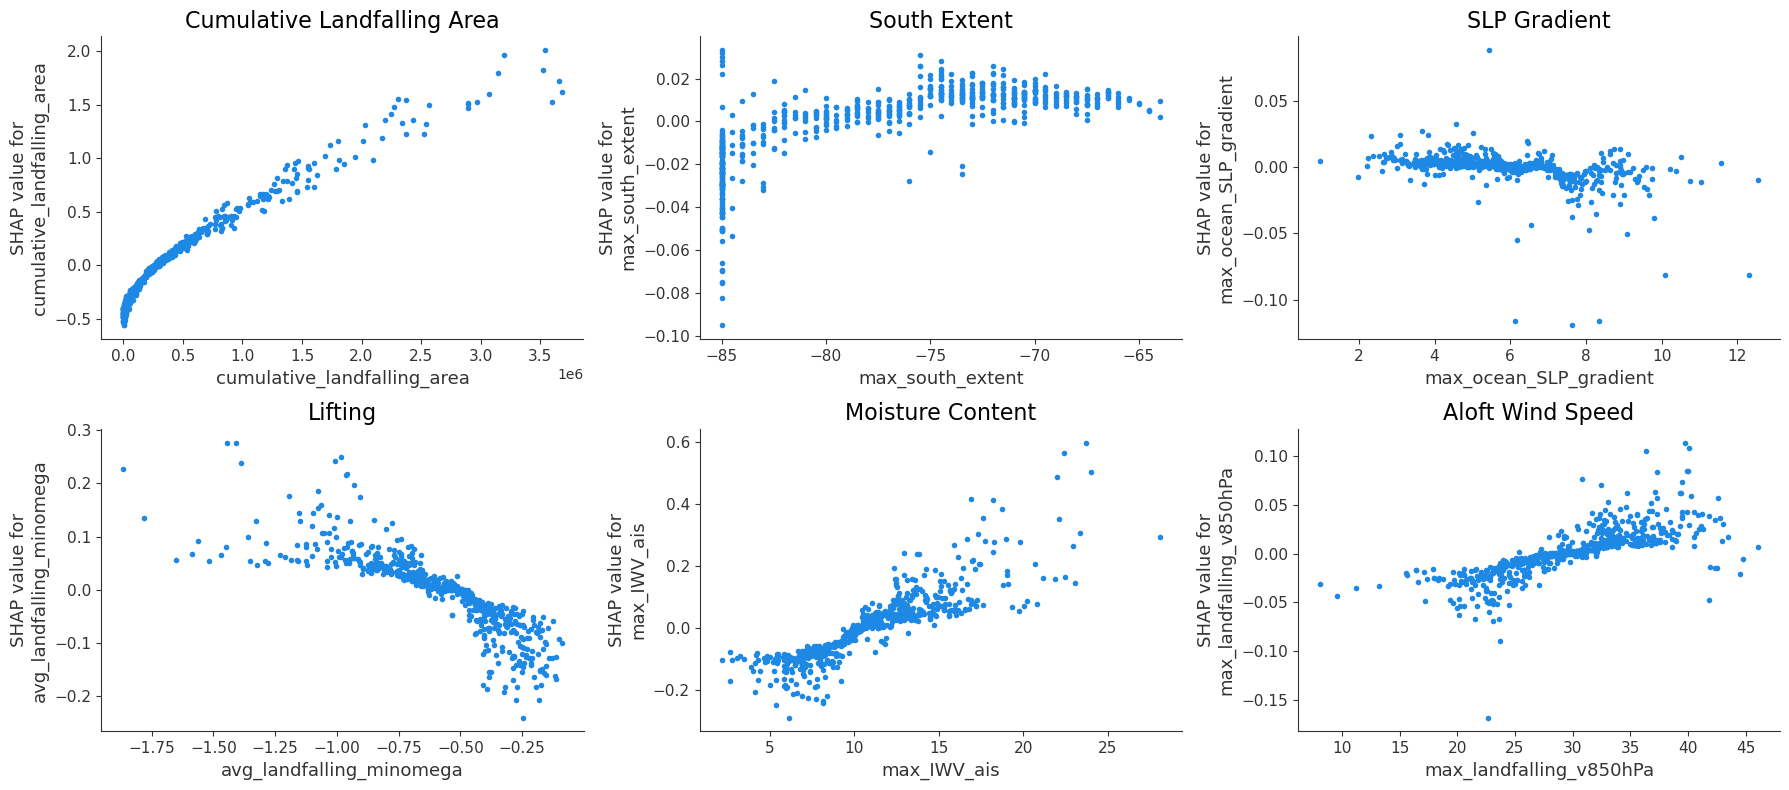

In [134]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 8))

plt.sca(axes[0,0])
shap.dependence_plot(
    ind="cumulative_landfalling_area",
    shap_values=shap_values,
    features=X_test,
    interaction_index=None,
    ax=axes[0,0],
    show=False)

axes[0,0].set_title('Cumulative Landfalling Area', fontsize=16);

plt.sca(axes[0,1])
shap.dependence_plot(
    ind="max_south_extent",
    shap_values=shap_values,
    features=X_test,
    interaction_index=None,
    ax=axes[0,1],
    show=False)

axes[0,1].set_title('South Extent', fontsize=16);

plt.sca(axes[0,2])
shap.dependence_plot(
    ind="max_ocean_SLP_gradient",
    shap_values=shap_values,
    features=X_test,
    interaction_index=None,
    ax=axes[0,2],
    show=False)

axes[0,2].set_title('SLP Gradient', fontsize=16);

plt.sca(axes[1,0])
shap.dependence_plot(
    ind="avg_landfalling_minomega",
    shap_values=shap_values,
    features=X_test,
    interaction_index=None,
    ax=axes[1,0],
    show=False)
axes[1,0].set_title('Lifting', fontsize=16);

plt.sca(axes[1,1])
shap.dependence_plot(
    ind="max_IWV_ais",
    shap_values=shap_values,
    features=X_test,
    interaction_index=None,
    ax=axes[1,1],
    show=False)
axes[1,1].set_title('Moisture Content', fontsize=16);

plt.sca(axes[1,2])
shap.dependence_plot(
    ind="max_landfalling_v850hPa",
    shap_values=shap_values,
    features=X_test,
    interaction_index=None,
    ax=axes[1,2],
    show=False)
axes[1,2].set_title('Aloft Wind Speed', fontsize=16);

plt.tight_layout()
plt.show()

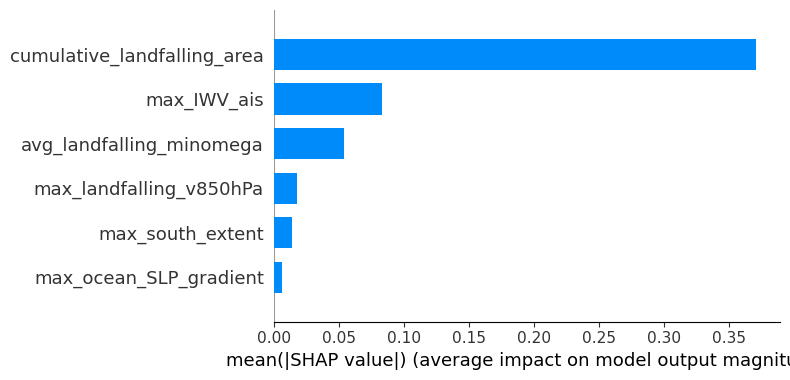

In [135]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

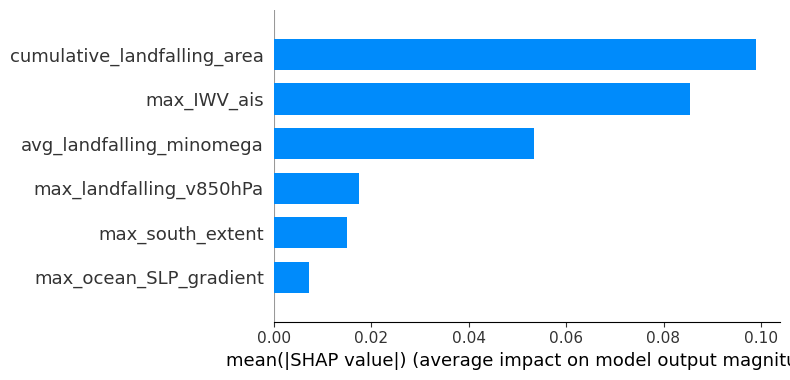

In [136]:
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar")

## Temp Model

In [107]:
with open('cross_validation/best_temp_xgb.json', 'r') as file:
        best_temp = json.load(file)

In [108]:
best_temp

{'gamma': 100.0,
 'max_depth': 3.0,
 'reg_lambda': 0.075,
 'min_child_weight': 0.0,
 'subsample_frac': 0.2,
 'eta': 0.005,
 'num_boost': 1454.0,
 'shrinkage_factor': 1.0048362016677856}

In [109]:
hyperparam_dict = {}
hyperparam_dict['gamma'] = float(best_temp['gamma'])
hyperparam_dict['max_depth'] = int(best_temp['max_depth'])
hyperparam_dict['reg_lambda'] = float(best_temp['reg_lambda'])
hyperparam_dict['min_child_weight'] = float(best_temp['min_child_weight'])
hyperparam_dict['eta'] = float(best_temp['eta'])
hyperparam_dict['booster'] = 'gbtree'
hyperparam_dict['tree_method'] = 'exact'
hyperparam_dict['objective'] = 'reg:squarederror'
hyperparam_dict['eval_metric'] = 'rmse'
num_boost = int(best_temp['num_boost'])
shrinkage_factor = best_temp['shrinkage_factor']

In [110]:
load_path = Path(os.getcwd()).parents[1]/'dataset/datasets/model_ready'

In [111]:
train_data = pd.read_csv(load_path/'train.csv', index_col='Label')
test_data = pd.read_csv(load_path/'test.csv', index_col='Label')
y_col = 'max_T2M_anomaly_ais'
x_cols = ['max_ocean_SLP_gradient', 'max_landfalling_v850hPa', 'avg_landfalling_minomega', 'max_IWV_ais', 'cumulative_landfalling_area', 'max_south_extent']

X_train = train_data[x_cols]
y_train = train_data[y_col]
X_test = test_data[x_cols]
y_test = test_data[y_col]
y_train_centered = y_train - y_train.mean()

X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])


In [112]:
model_temp = xgb.XGBRegressor(n_estimators=num_boost, 
                     max_depth=hyperparam_dict['max_depth'], 
                     learning_rate=hyperparam_dict['eta'],
                     booster=hyperparam_dict['booster'],
                     tree_method=hyperparam_dict['tree_method'],
                     gamma=hyperparam_dict['gamma'],
                     min_child_weight=hyperparam_dict['min_child_weight'],
                     reg_lambda=hyperparam_dict['reg_lambda'],
                     objective='reg:squarederror',
                     eval_metric='rmse')

temp_fit = model_temp.fit(X_train, y_train_centered)

In [113]:
def prediction_temp(X, y_train, model_fit, shrinkage_factor, centered=False):
    pred = shrinkage_factor*(model_fit.predict(X))

    if not centered:
        return pred + y_train.mean()
    return pred

In [114]:
y_test_pred = prediction_temp(X_test, y_train, temp_fit, shrinkage_factor)
y_train_pred = prediction_temp(X_train, y_train, temp_fit, shrinkage_factor)

In [115]:
## training predictive r-squared
train_pred_r2 = predictive_r2(y_train_pred, y_train)

## testing predictive r-squared
test_pred_r2 = predictive_r2(y_test_pred, y_test)

## ols baseline
reg = LinearRegression().fit(X_train, y_train_centered)
y_pred_ols = reg.predict(X_test) + y_train.mean()
test_ols_r2 = predictive_r2(y_pred_ols, y_test)

In [116]:
test_pred_r2

np.float64(0.5553291473599233)

In [117]:
test_ols_r2

np.float64(0.5014282815927427)

By what percentage did our xgboost model close the gap between perfection and OLS?

In [118]:
(test_pred_r2 - test_ols_r2)/(1-test_ols_r2)

np.float64(0.10811055616907628)

### Model Interpretation

Like before, we'll first dive in with a variable importance analysis by way of permutation scores. Then, we'll pick the most important variables and look at some associations.

In [119]:
importances = get_permutation_importance(lambda X: prediction_temp(X, y_train=y_train, model_fit=temp_fit, shrinkage_factor=shrinkage_factor),
                               X_full, y_full, predictive_r2, maximize=True, n_repeats=500)
importances

,avg_importance,avg_importance_scaled
max_south_extent,0.420006,1.000000
cumulative_landfalling_area,0.295956,0.704648
max_IWV_ais,0.092373,0.219933
avg_landfalling_minomega,0.074645,0.177723
max_landfalling_v850hPa,0.040721,0.096953
max_ocean_SLP_gradient,0.014508,0.034542


/tmp/ipykernel_1141162/2588156734.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels);


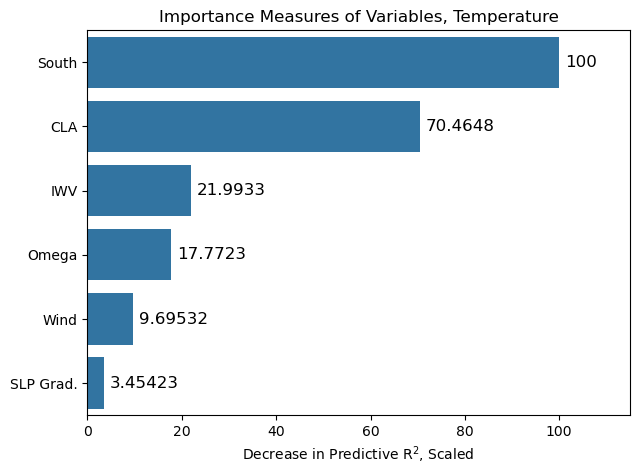

In [120]:
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=importances, y=importances.index, x=importances.avg_importance_scaled*100, ax=ax)
ax.set_title('Importance Measures of Variables, Temperature')
ax.set_xlabel('Decrease in Predictive R$^{2}$, Scaled')
ax.set_xlim([0,115])
ax.set_ylabel('')
ax.bar_label(ax.containers[0], padding=4, fontsize=12)
new_labels = ['South', 'CLA', 'IWV', 'Omega', 'Wind', 'SLP Grad.']
ax.set_yticklabels(new_labels);
fig.savefig('plots/importance_temp.png', dpi=300)

Interpretation: how far south the storm penetrates the continent is the most important variable, strongest predictor in our model of temperature anomaly. Seems like mostly a geographic phenomenon, as CLA also dominates. However, IWV, Omega, and Wind also play fairly significant roles.

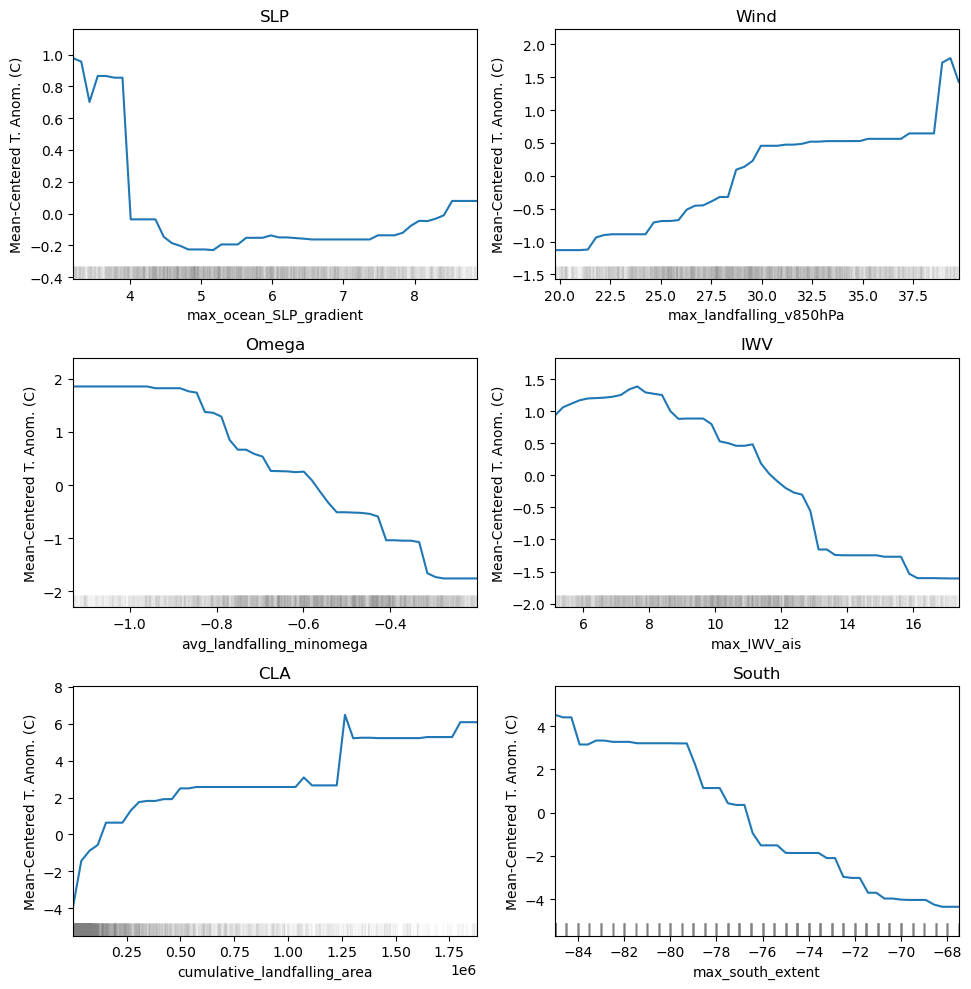

In [121]:
fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(10, 10))
axs = axs.flatten()
features = list(X_train.columns)

for i, ax in enumerate(axs):

    q = 0.05
    extents = [X_full[features[i]].quantile(q),
              X_full[features[i]].quantile(1-q)]
    
    grid, pdp_vals = compute_pdp_1d(features[i], 
                                              X_full, lambda X: prediction_temp(X, 
                                                                        y_train=y_train,
                                                                        model_fit=temp_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True), extents=extents)
    ax.plot(grid, pdp_vals)
    sns.rugplot(x=X_full[features[i]], ax=ax, height=0.05, color='gray', alpha=0.05)
    ax.set_title(abbv_dict[features[i]])
    ax.set_xlim(extents[0], extents[1])
    ax.set_ylabel('Mean-Centered T. Anom. (C)')

plt.tight_layout()
plt.savefig('temp_1d_pdp_full.png', dpi=300)

Let's make a plot of just southern extent and the three other atmospheric variables, since south will be our stand-in for geographic features. So, we'll be making similar plots as before, except instead of CLA our geographic variable will be southern extent.

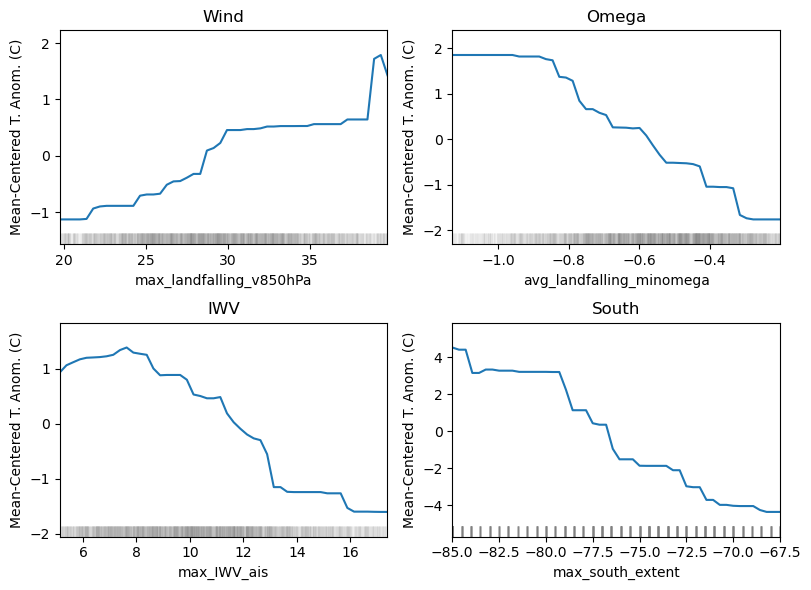

In [122]:
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(8, 6))
axs = axs.flatten()
features = list(X_train.columns[[1, 2, 3, 5]])

for i, ax in enumerate(axs):

    q = 0.05
    extents = [X_full[features[i]].quantile(q),
              X_full[features[i]].quantile(1-q)]
    
    grid, pdp_vals = compute_pdp_1d(features[i], 
                                              X_full, lambda X: prediction_temp(X, 
                                                                        y_train=y_train,
                                                                        model_fit=temp_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True), extents=extents)
    ax.plot(grid, pdp_vals)
    sns.rugplot(x=X_full[features[i]], ax=ax, height=0.05, color='gray', alpha=0.05)
    ax.set_title(abbv_dict[features[i]])
    ax.set_xlim(extents[0], extents[1])
    ax.set_ylabel('Mean-Centered T. Anom. (C)')

plt.tight_layout()
plt.savefig('temp_1d_pdp_subset.png', dpi=300)

Interpretation: holding all other variables fixed, making an AR go further south on the continent increases temperature anomaly predictions to the greatest degree. It also seems like if you make a storm drier, then temperature anomaly predictions increase, as well as if you have more lifting. Increasing landfalling aloft winds increases temperature predictions (with all other variables fixed), although much more modestly than the other variables.

In [123]:
import itertools
combos = list(itertools.combinations(X_test.columns, 2))

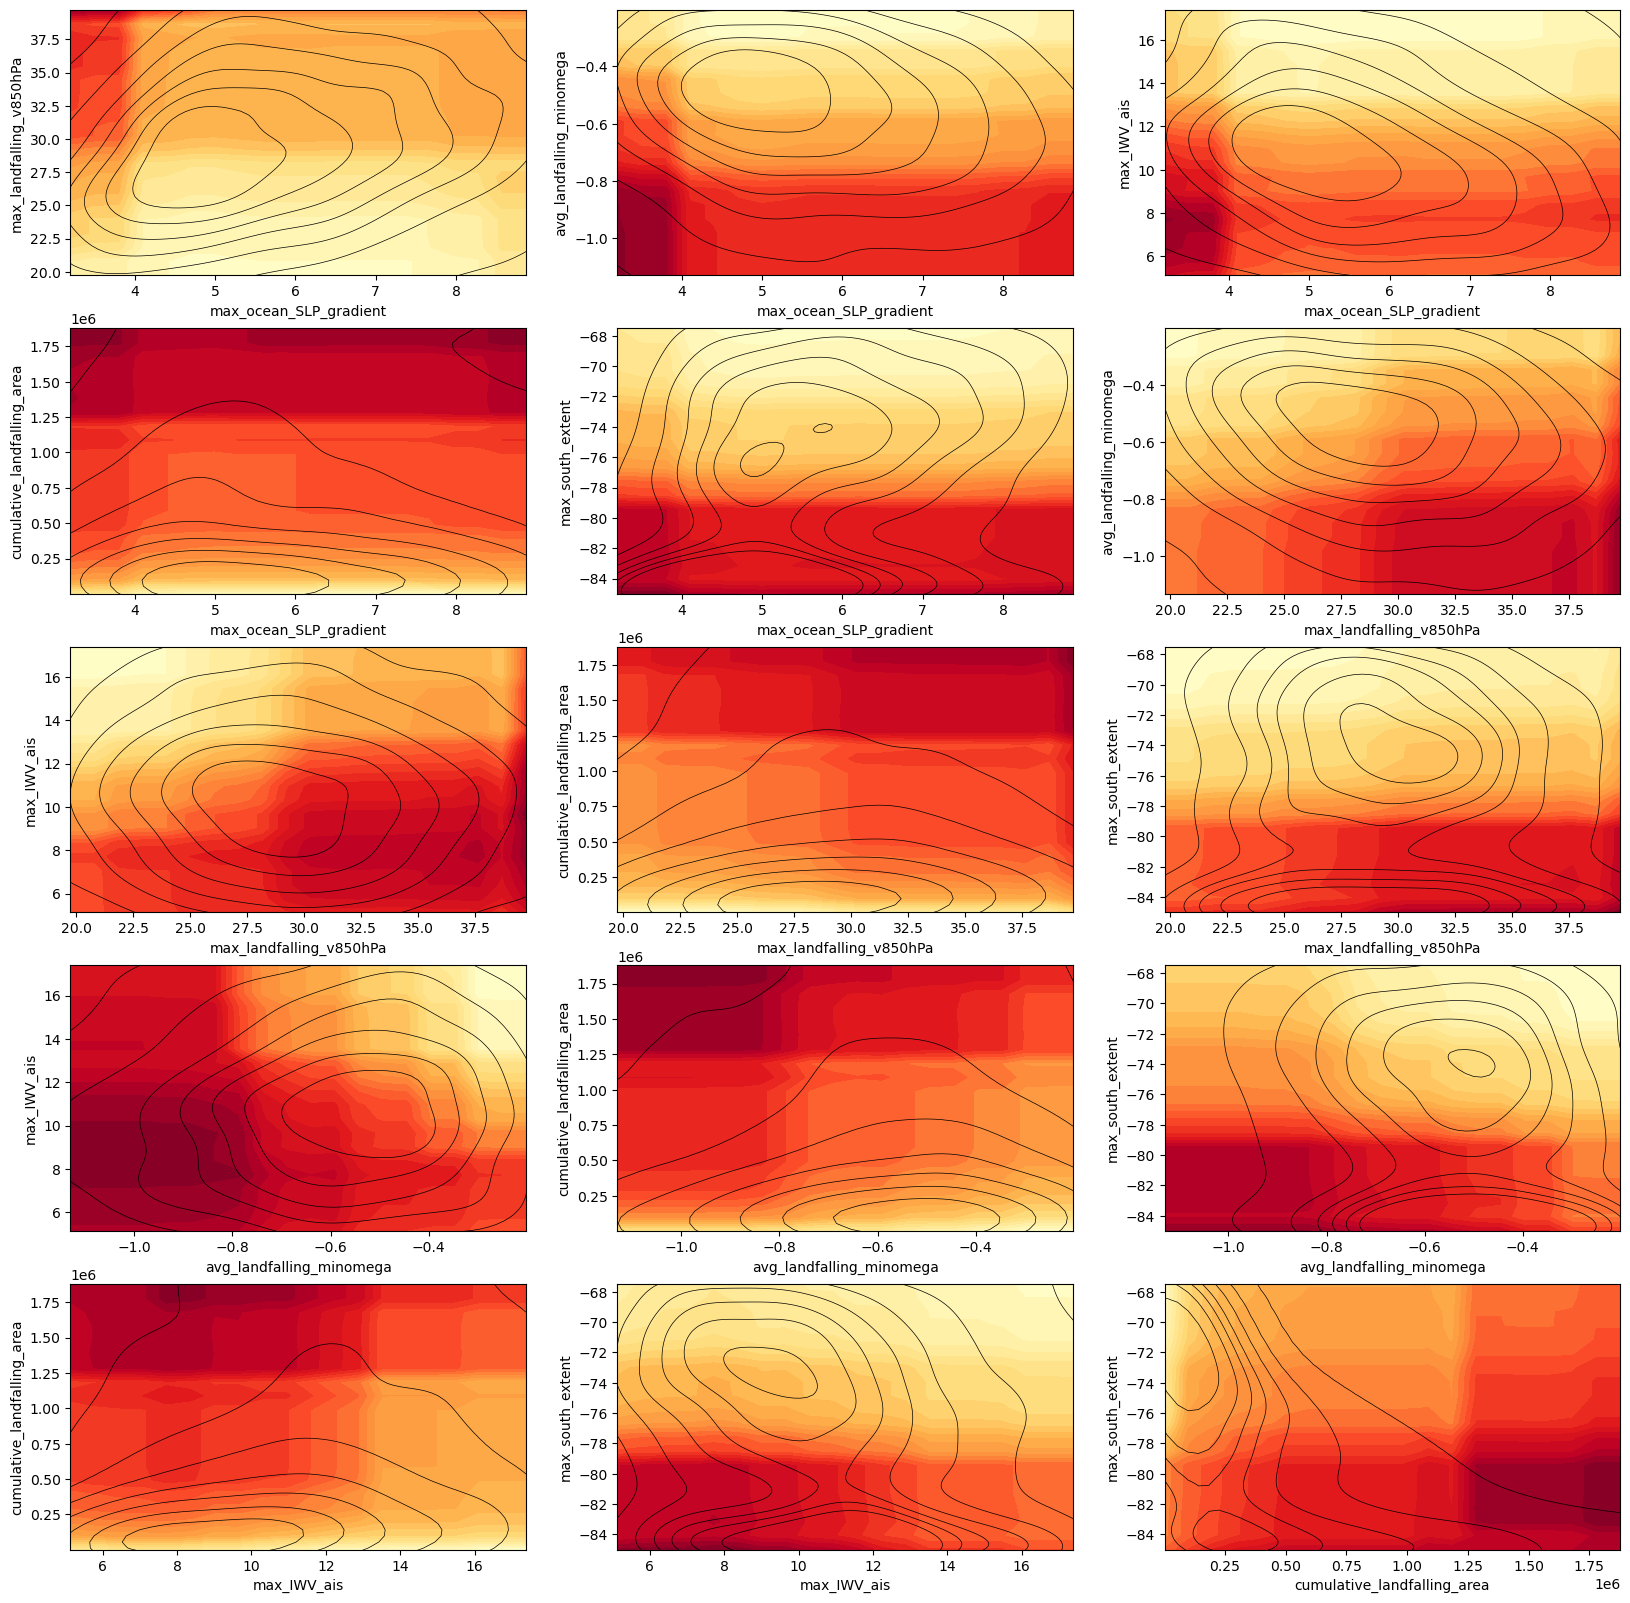

In [124]:
fig, axs = plt.subplots(ncols=3, nrows=5, figsize=(20, 20))

axs = axs.flatten()

for i, ax in enumerate(axs):
    combo = combos[i]

    q = 0.05 # quantile to clip data
    extents = [X_full[combo[0]].quantile(q), 
               X_full[combo[0]].quantile(1-q),
               X_full[combo[1]].quantile(q),
               X_full[combo[1]].quantile(1-q)]

    grid1, grid2, pdp_matrix = compute_pdp_2d(combo[0], combo[1], 
                                              X_full, lambda X: prediction_temp(X, 
                                                                        y_train=y_train, 
                                                                        model_fit=temp_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True),
                                              extents=extents)
    ax.contourf(grid1, grid2, pdp_matrix, cmap='YlOrRd', levels=25)
    sns.kdeplot(x=X_full[combo[0]], y=X_full[combo[1]], ax=ax, levels=8, color="black", linewidths=0.5, fill=False)
    ax.set_ylim(min(grid2), max(grid2))
    ax.set_xlim(min(grid1), max(grid1))
    ax.set_xlabel(combo[0])
    ax.set_ylabel(combo[1])

plt.savefig('temp_2d_pdp_full.png', dpi=300)

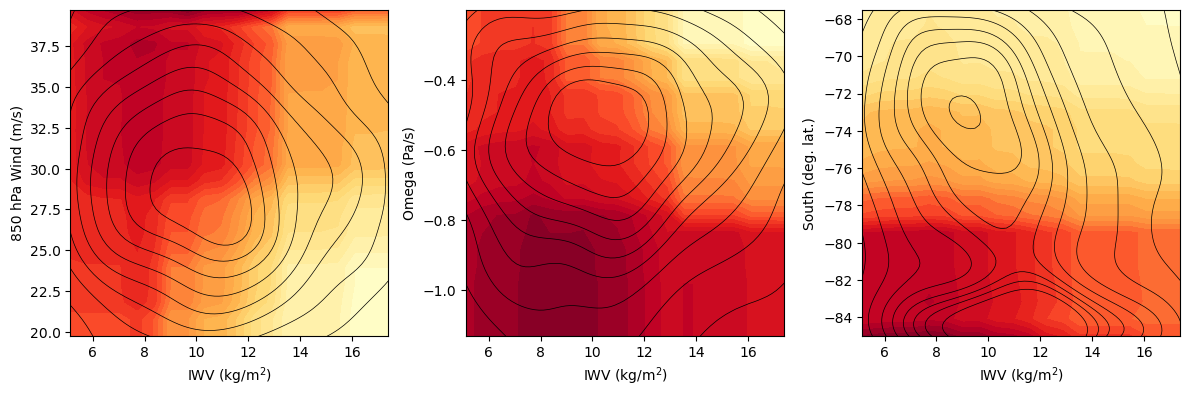

In [125]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))

axs = axs.flatten()

combos = [('max_IWV_ais', 'max_landfalling_v850hPa'),
          ('max_IWV_ais', 'avg_landfalling_minomega'),
          ('max_IWV_ais', 'max_south_extent')]

for i, ax in enumerate(axs):
    combo = combos[i]

    q = 0.05 # quantile to clip data
    extents = [X_full[combo[0]].quantile(q), 
               X_full[combo[0]].quantile(1-q),
               X_full[combo[1]].quantile(q),
               X_full[combo[1]].quantile(1-q)]

    grid1, grid2, pdp_matrix = compute_pdp_2d(combo[0], combo[1], 
                                              X_full, lambda X: prediction_temp(X, 
                                                                        y_train=y_train, 
                                                                        model_fit=temp_fit,
                                                                        shrinkage_factor=shrinkage_factor,
                                                                        centered=True), extents=extents)
    ax.contourf(grid1, grid2, pdp_matrix, cmap='YlOrRd', levels=25)
    sns.kdeplot(x=X_train[combo[0]], y=X_train[combo[1]], ax=ax, levels=10, color="black", linewidths=0.5, fill=False)
    ax.set_ylim(min(grid2), max(grid2))
    ax.set_xlim(min(grid1), max(grid1))
    ax.set_xlabel(combo[0])
    ax.set_ylabel(combo[1])

plt.tight_layout()

axs[0].set_ylabel('850 hPa Wind (m/s)')
axs[0].set_xlabel('IWV (kg/m$^{2}$)')
axs[1].set_ylabel('Omega (Pa/s)')
axs[1].set_xlabel('IWV (kg/m$^{2}$)')
axs[2].set_ylabel('South (deg. lat.)')
axs[2].set_xlabel('IWV (kg/m$^{2}$)');

plt.savefig('plots/temp_2d_pdp_subset.png', dpi=300)

Interpretations:

+ Predicted temperature anomalies are much higher for wind-dominated ARs than moisture dominated ARs, holding all other variables constant.
+ Drier ARs with more lifting have higher temperature anomalies.
+ Southern extent plays a pretty significant role, but after a certain point it doesn't increase much further, and any further increases in predictions seem driven by wind-speed.

#### SHAP Analysis

As before, we also interrogate this model by way of Shapley values.

In [151]:
explainer_full = shap.KernelExplainer(
    model=prediction_temp,
    data=X_train
)
shap_values_temp = explainer_full.shap_values(X_test)

  0%|          | 0/620 [00:00<?, ?it/s]

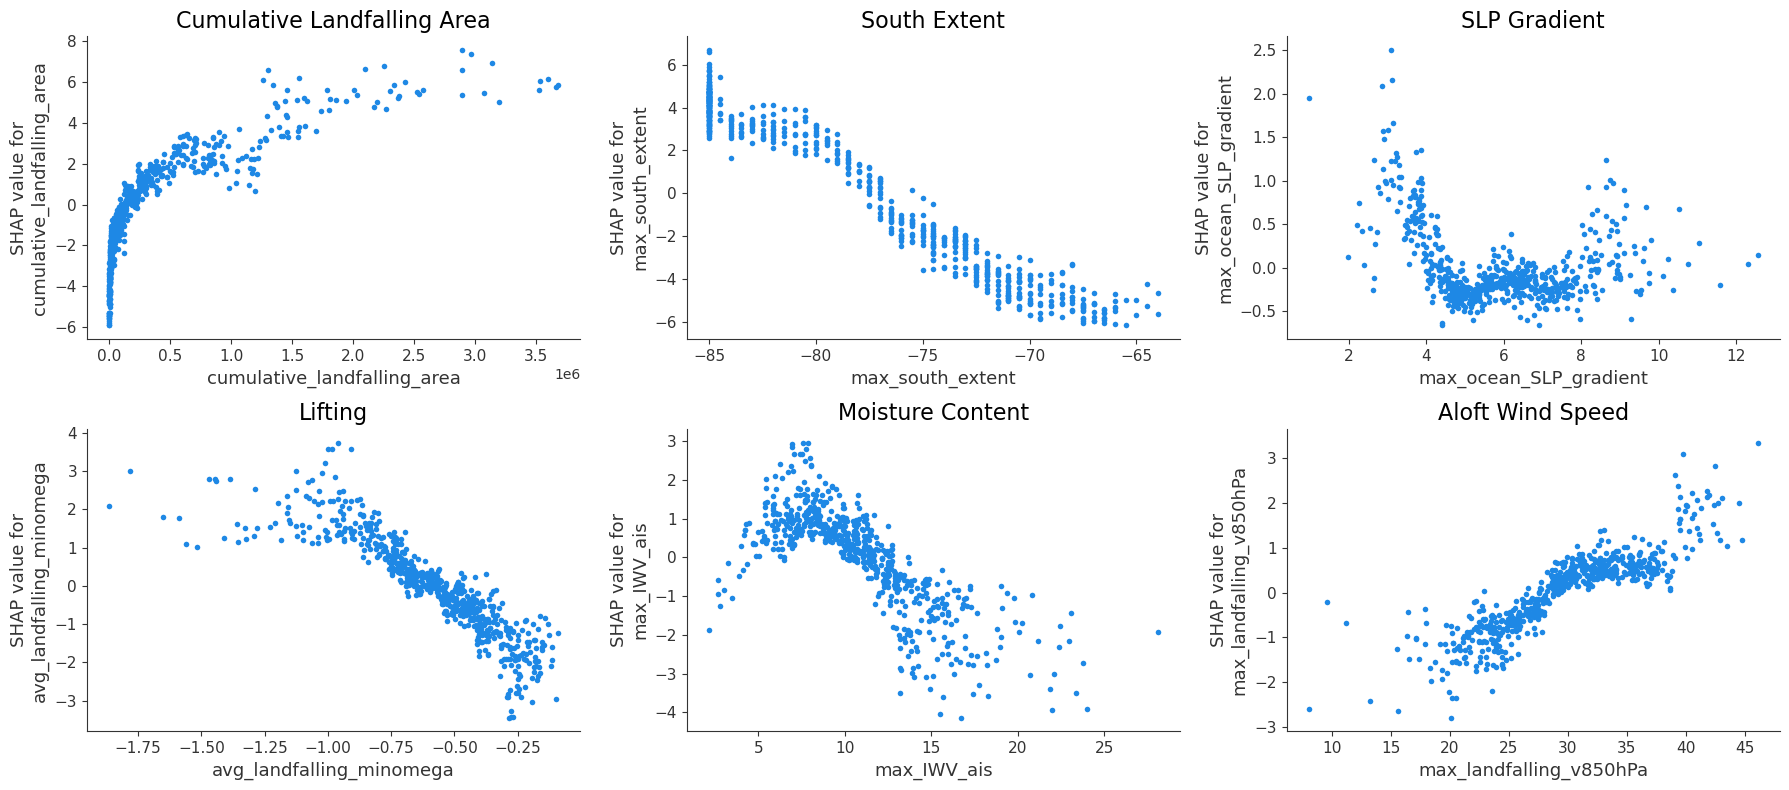

In [152]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 8))

plt.sca(axes[0,0])
shap.dependence_plot(
    ind="cumulative_landfalling_area",
    shap_values=shap_values_temp,
    features=X_test,
    interaction_index=None,
    ax=axes[0,0],
    show=False)

axes[0,0].set_title('Cumulative Landfalling Area', fontsize=16);

plt.sca(axes[0,1])
shap.dependence_plot(
    ind="max_south_extent",
    shap_values=shap_values_temp,
    features=X_test,
    interaction_index=None,
    ax=axes[0,1],
    show=False)

axes[0,1].set_title('South Extent', fontsize=16);

plt.sca(axes[0,2])
shap.dependence_plot(
    ind="max_ocean_SLP_gradient",
    shap_values=shap_values_temp,
    features=X_test,
    interaction_index=None,
    ax=axes[0,2],
    show=False)

axes[0,2].set_title('SLP Gradient', fontsize=16);

plt.sca(axes[1,0])
shap.dependence_plot(
    ind="avg_landfalling_minomega",
    shap_values=shap_values_temp,
    features=X_test,
    interaction_index=None,
    ax=axes[1,0],
    show=False)
axes[1,0].set_title('Lifting', fontsize=16);

plt.sca(axes[1,1])
shap.dependence_plot(
    ind="max_IWV_ais",
    shap_values=shap_values_temp,
    features=X_test,
    interaction_index=None,
    ax=axes[1,1],
    show=False)
axes[1,1].set_title('Moisture Content', fontsize=16);

plt.sca(axes[1,2])
shap.dependence_plot(
    ind="max_landfalling_v850hPa",
    shap_values=shap_values_temp,
    features=X_test,
    interaction_index=None,
    ax=axes[1,2],
    show=False)
axes[1,2].set_title('Aloft Wind Speed', fontsize=16);

plt.tight_layout()
plt.show()

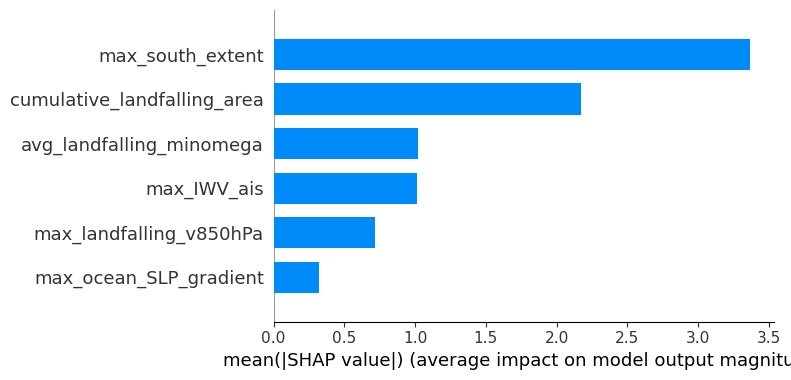

In [153]:
shap.summary_plot(shap_values_temp, X_test, plot_type="bar")